In [29]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import re
import pyproj
import folium

In [30]:
dia = '20260308'

In [31]:
#Tabla acciones regulación SAE

acciones_SAE = pd.read_csv(f'Z:/01 base_datos/09 acciones_regulacion_FMS/{dia}_accionesregulacion.csv',encoding='latin')

acciones_SAE.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,8/03/2026,1:53:08,10550,P500,NaN,NaN,NaN,22,Desvios,SmartCore,NaN,<= Detour Deactive =>\nSecuenciaDesvío=73568,0,Desvío,NaN
1,8/03/2026,1:53:08,10550,P500,NaN,NaN,NaN,22,Desvios,SmartCore,NaN,<= Detour Deactive =>\nSecuenciaDesvío=73569,0,Desvío,NaN
2,8/03/2026,2:03:21,10325,576,NaN,NaN,NaN,22,Desvios,ARIANO_105,ANGELA MIREYA RIAÑO PASITO,<= Detour Deactive =>\nSecuenciaDesvío=87938,59,Desvío,NaN
3,8/03/2026,2:03:23,10325,576,NaN,NaN,NaN,22,Desvios,ARIANO_105,ANGELA MIREYA RIAÑO PASITO,<= Detour Active =>\nSecuenciaDesvío=87938,59,Desvío,NaN
4,8/03/2026,2:04:06,10325,576,NaN,NaN,NaN,22,Desvios,ARIANO_105,ANGELA MIREYA RIAÑO PASITO,<= Detour Deactive =>\nSecuenciaDesvío=100678,59,Desvío,NaN


In [32]:
# Extraer la hora antes del primer :
acciones_SAE['Franja'] = (
    acciones_SAE['Instante']
    .astype(str)
    .str.split(':')
    .str[0]
)

# Convertir a entero
acciones_SAE['Franja'] = pd.to_numeric(
    acciones_SAE['Franja'],
    errors='coerce'
).fillna(0).astype(int)

acciones_SAE.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Franja
0,8/03/2026,1:53:08,10550,P500,NaN,NaN,NaN,22,Desvios,SmartCore,NaN,<= Detour Deactive =>\nSecuenciaDesvío=73568,0,Desvío,NaN,1
1,8/03/2026,1:53:08,10550,P500,NaN,NaN,NaN,22,Desvios,SmartCore,NaN,<= Detour Deactive =>\nSecuenciaDesvío=73569,0,Desvío,NaN,1
2,8/03/2026,2:03:21,10325,576,NaN,NaN,NaN,22,Desvios,ARIANO_105,ANGELA MIREYA RIAÑO PASITO,<= Detour Deactive =>\nSecuenciaDesvío=87938,59,Desvío,NaN,2
3,8/03/2026,2:03:23,10325,576,NaN,NaN,NaN,22,Desvios,ARIANO_105,ANGELA MIREYA RIAÑO PASITO,<= Detour Active =>\nSecuenciaDesvío=87938,59,Desvío,NaN,2
4,8/03/2026,2:04:06,10325,576,NaN,NaN,NaN,22,Desvios,ARIANO_105,ANGELA MIREYA RIAÑO PASITO,<= Detour Deactive =>\nSecuenciaDesvío=100678,59,Desvío,NaN,2


In [33]:
# Filtrar solo acciones 5, 36 y 4
acciones_SAE = acciones_SAE[
    acciones_SAE['Id Acción'].isin([5, 36, 4])
]

acciones_SAE.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Franja
331,8/03/2026,7:15:55,10350,SE14,3.0,Z50-7023,507023.0,5,Eliminar Vehiculo,DROJAS_105,DEISY YANIRA ROJAS TORRES,"<= Elimination Vehicle =>\nIdLinea=10350,\nSer...",2,Bus varado en la via,NaN,7
332,8/03/2026,7:17:01,10350,SE14,3.0,NaN,0.0,5,Eliminar Vehiculo,DROJAS_105,DEISY YANIRA ROJAS TORRES,"<= Elimination Vehicle =>\nIdLinea=10350,\nSer...",1,Concesionario no envía vehículo,NaN,7
342,8/03/2026,7:31:22,10273,142,5.0,Z50-2104,502104.0,5,Eliminar Vehiculo,JESPINOSA_105,JHON JAIRO ESPINOSA SANTA,"<= Elimination Vehicle =>\nIdLinea=10273,\nSer...",19,Fallas del SIRCI,NaN,7
347,8/03/2026,7:37:49,10325,576,14.0,Z50-2133,502133.0,5,Eliminar Vehiculo,JESPINOSA_105,JHON JAIRO ESPINOSA SANTA,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",7,Bus Retrasado,NaN,7
349,8/03/2026,7:39:44,10264,614,6.0,Z50-4318,504318.0,36,Retomar Viajes,DROJAS_105,DEISY YANIRA ROJAS TORRES,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,7


In [34]:
acciones_SAE = acciones_SAE[

    (
        acciones_SAE['Id Acción'].isin([4, 36])
    )

    |

    (
        (acciones_SAE['Id Acción'] == 5)
        &
        (acciones_SAE['Id Motivo'] == 5)
    )

]

acciones_SAE.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Franja
349,8/03/2026,7:39:44,10264,614,6.0,Z50-4318,504318.0,36,Retomar Viajes,DROJAS_105,DEISY YANIRA ROJAS TORRES,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,7
358,8/03/2026,7:49:24,10310,C101,4.0,Z50-4433,504433.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,7
407,8/03/2026,8:16:24,10350,SE14,1.0,Z50-7033,507033.0,36,Retomar Viajes,DROJAS_105,DEISY YANIRA ROJAS TORRES,"<= Change Vehicle =>\nIdLinea=10350,\nServBusR...",26,Retoma de viaje,NaN,8
410,8/03/2026,8:21:27,10310,C101,5.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,8
423,8/03/2026,8:35:34,10292,577,5.0,Z50-4507,504507.0,36,Retomar Viajes,JESPINOSA_105,JHON JAIRO ESPINOSA SANTA,"<= Change Vehicle =>\nIdLinea=10292,\nServBusR...",26,Retoma de viaje,NaN,8


In [37]:
print(acciones_SAE['Motivo'].unique())

['Retoma de viaje' 'Congestion vehicular']


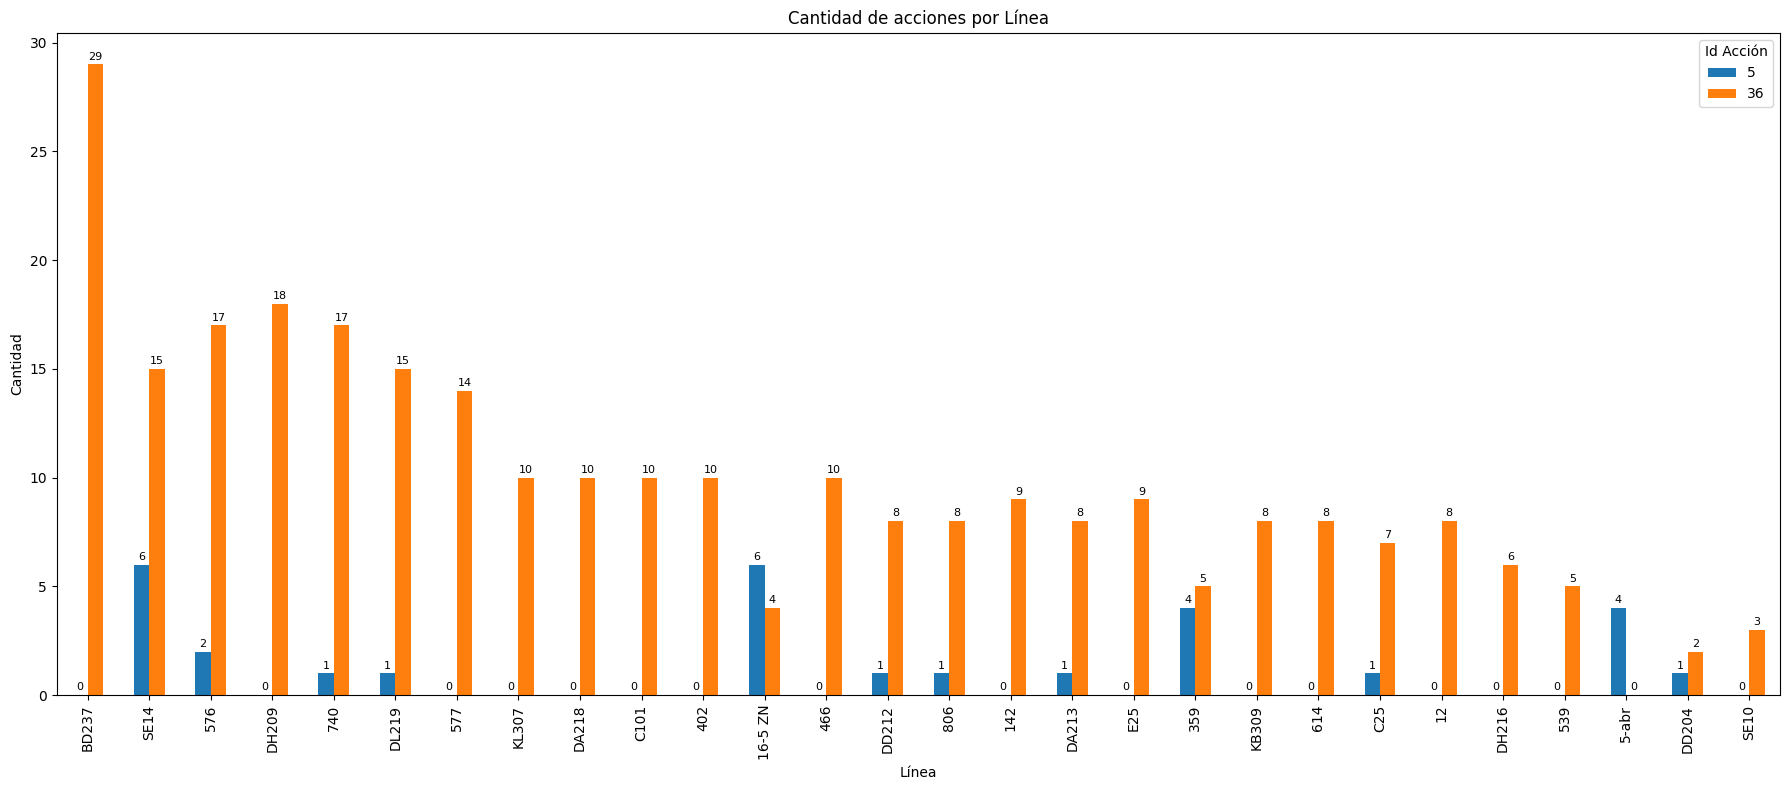

In [39]:
# Filtrar acciones
acciones_filtradas = acciones_SAE[
    acciones_SAE['Id Acción'].isin([5, 4, 36])
]

# Agrupar
grafica_acciones = (
    acciones_filtradas
    .groupby(['Línea', 'Id Acción'])
    .size()
    .reset_index(name='Cantidad')
)

# Pivotear
grafica_pivot = grafica_acciones.pivot(
    index='Línea',
    columns='Id Acción',
    values='Cantidad'
).fillna(0)

# Ordenar por total
grafica_pivot['Total'] = grafica_pivot.sum(axis=1)

grafica_pivot = grafica_pivot.sort_values(
    'Total',
    ascending=False
)

# Eliminar total
grafica_pivot = grafica_pivot.drop(columns='Total')

# Crear gráfica
ax = grafica_pivot.plot(
    kind='bar',
    figsize=(18,8)
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%.0f',
        padding=2,
        fontsize=8
    )


plt.title('Cantidad de acciones por Línea')
plt.xlabel('Línea')
plt.ylabel('Cantidad')

# Rotar etiquetas eje X
plt.xticks(rotation=90)

# Leyenda
plt.legend(title='Id Acción')

plt.tight_layout()

plt.show()

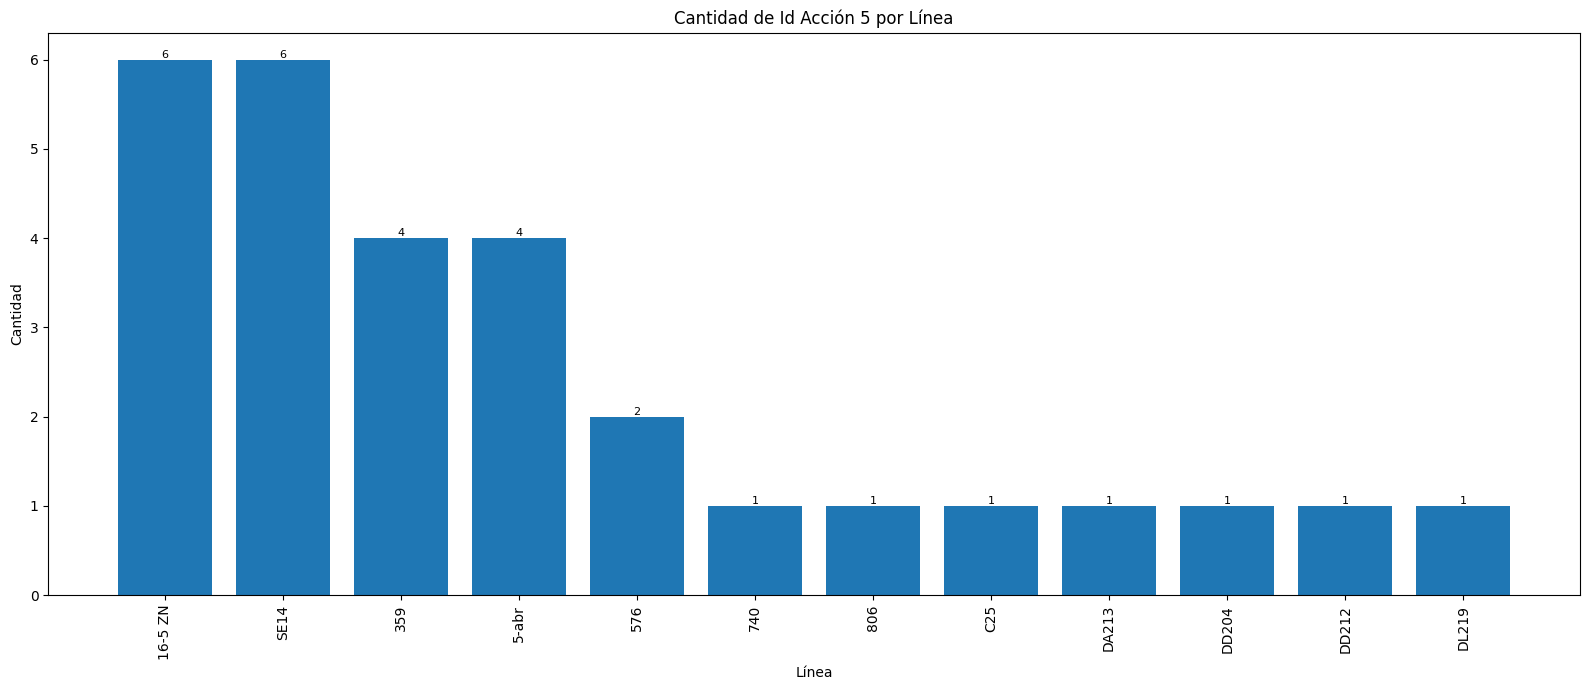

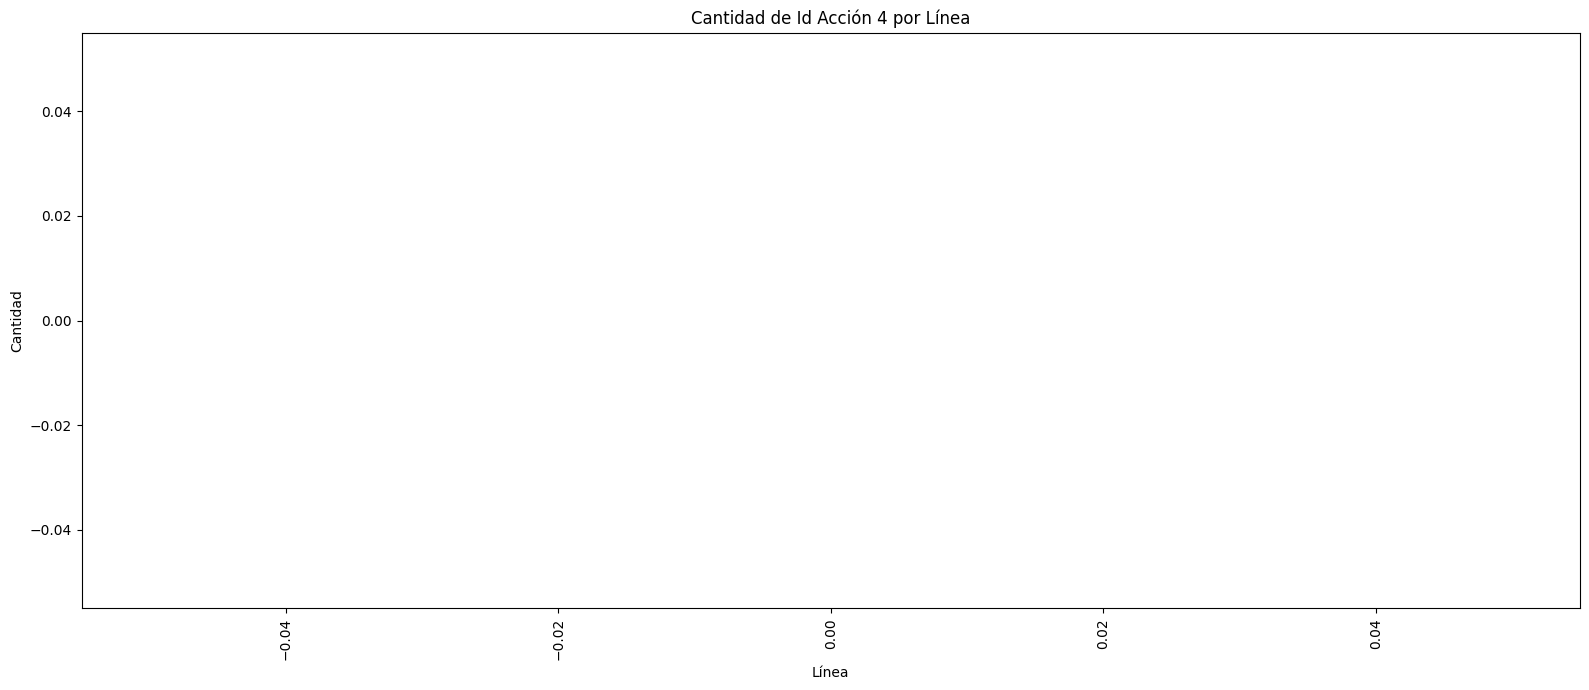

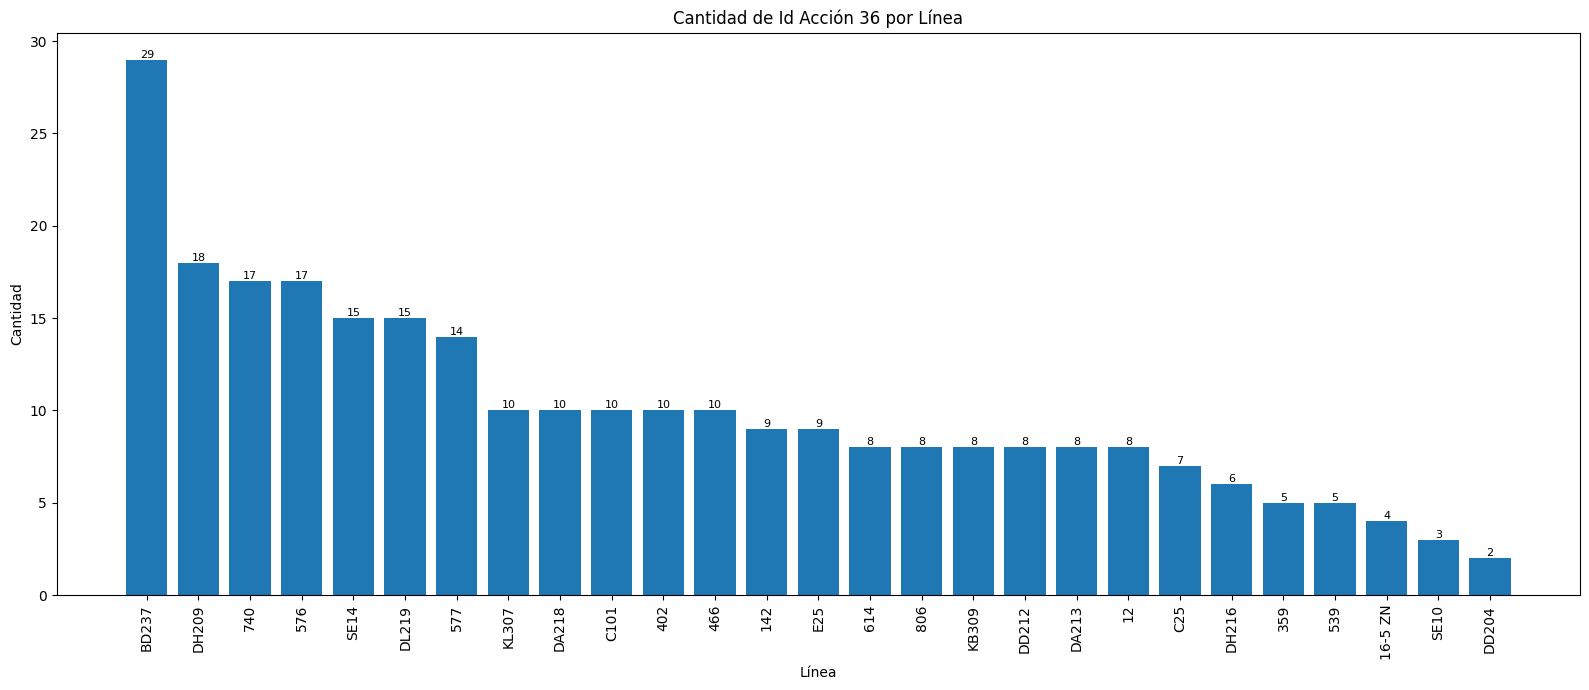

In [41]:
import matplotlib.pyplot as plt

# Filtrar acciones
acciones_filtradas = acciones_SAE[
    acciones_SAE['Id Acción'].isin([5, 4, 36])
]

# Lista acciones
acciones_ids = [5, 4, 36]

# Crear una gráfica por cada acción
for accion in acciones_ids:

    # Filtrar acción
    temp = acciones_filtradas[
        acciones_filtradas['Id Acción'] == accion
    ]

    # Agrupar
    grafica = (
        temp
        .groupby('Línea')
        .size()
        .reset_index(name='Cantidad')
        .sort_values(
            'Cantidad',
            ascending=False
        )
    )

    # Crear figura
    plt.figure(figsize=(16,7))

    bars = plt.bar(
        grafica['Línea'].astype(str),
        grafica['Cantidad']
    )


    for bar in bars:

        altura = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            altura,
            f'{int(altura)}',
            ha='center',
            va='bottom',
            fontsize=8
        )



    plt.title(f'Cantidad de Id Acción {accion} por Línea')

    plt.xlabel('Línea')
    plt.ylabel('Cantidad')

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.show()

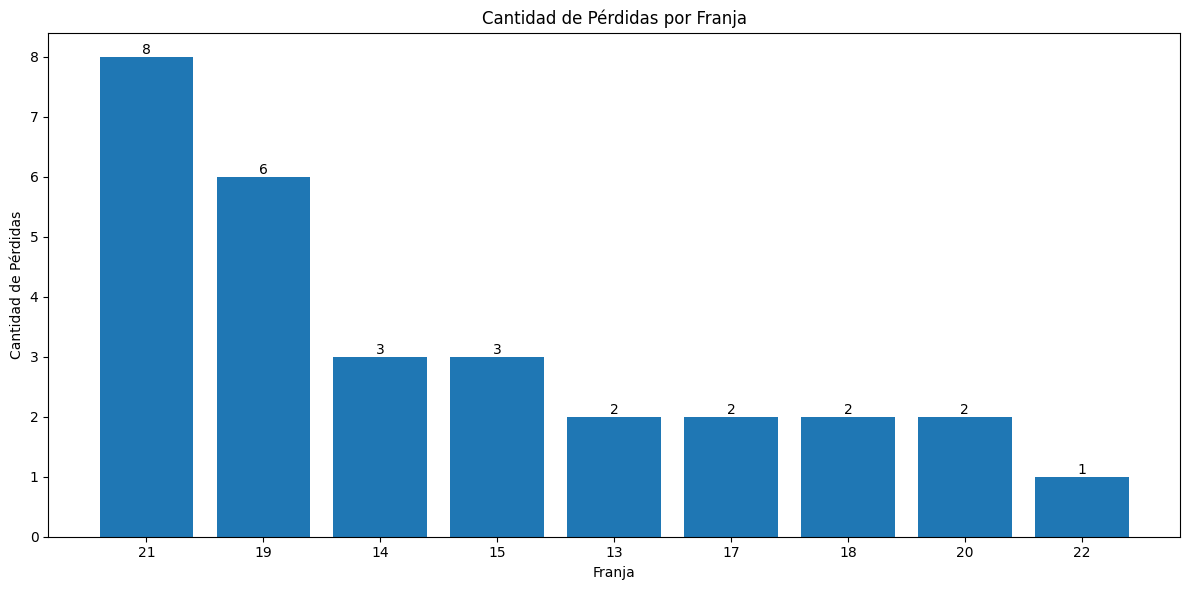

In [46]:
perdidas = acciones_SAE[
    (acciones_SAE['Id Acción'] == 5) &
    (acciones_SAE['Id Motivo'] == 5)
]



grafica = (
    perdidas
    .groupby('Franja')
    .size()
    .reset_index(name='Cantidad')
    .sort_values('Cantidad', ascending=False)
)


plt.figure(figsize=(12,6))

bars = plt.bar(
    grafica['Franja'].astype(str),
    grafica['Cantidad']
)


for bar in bars:

    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f'{int(altura)}',
        ha='center',
        va='bottom',
        fontsize=10
    )


plt.title('Cantidad de Pérdidas por Franja')

plt.xlabel('Franja')

plt.ylabel('Cantidad de Pérdidas')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

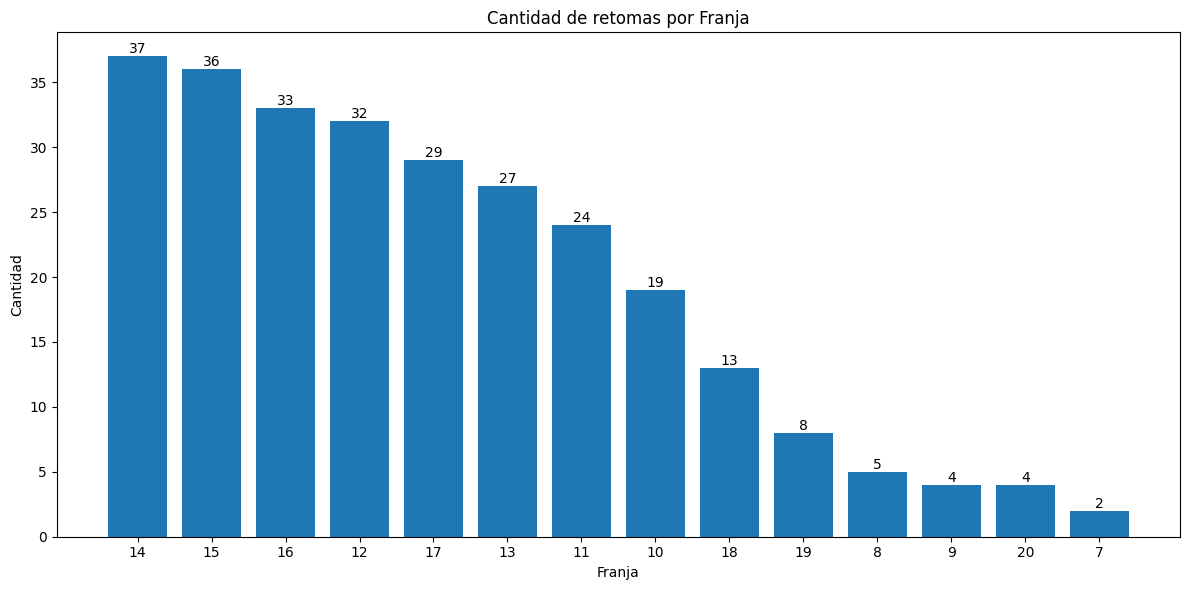

In [48]:
accion_36 = acciones_SAE[
    acciones_SAE['Id Acción'] == 36
]


grafica = (
    accion_36
    .groupby('Franja')
    .size()
    .reset_index(name='Cantidad')
    .sort_values('Cantidad', ascending=False)
)


plt.figure(figsize=(12,6))

bars = plt.bar(
    grafica['Franja'].astype(str),
    grafica['Cantidad']
)



for bar in bars:

    altura = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f'{int(altura)}',
        ha='center',
        va='bottom',
        fontsize=10
    )


plt.title('Cantidad de retomas por Franja')

plt.xlabel('Franja')

plt.ylabel('Cantidad')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()